# Data Preprocessing

In [ ]:

# We begin by loading the synthetic dataset of 100,000 patients and preparing it for modeling. The target variable is **`macro_cluster`** (C1–C10), which represents the patient's behavioral archetype cluster. We drop non-predictive or outcome-derived fields (`patient_id`, `ttm_init`, `risk_tier`, `arch_prior`, `flags`, `ttm_band`, `subcluster_id`) to avoid data leakage. The remaining features include demographics (age, sex, race, BMI, AF type), clinical comorbidities (e.g. hypertension, diabetes), treatment info (e.g. OAC drug), and behavioral/engagement metrics like motivation, risk perception, literacy confidence, autonomy, digital comfort, caregiver support level, portal activity, etc:contentReference[oaicite:0]{index=0}. We will encode categorical features (e.g. sex, race, AF type, OAC drug, caregiver_support) and normalize numeric features. Boolean fields (True/False) will be converted to binary 0/1 indicators. We also handle missing values: for instance, the `inr` lab value is missing for most patients (those not on warfarin), so we drop it since warfarin usage is captured by other features (OAC drug and an `inr_unstable` flag).

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('synth_AF_clusters_100k.csv')

# Define target and columns to drop
target = 'macro_cluster'
drop_cols = ['patient_id', 'ttm_init', 'risk_tier', 'arch_prior', 'flags', 'ttm_band', 'subcluster_id', 'inr']
X = df.drop(columns=[target] + drop_cols)
y = df[target].copy()

# Convert categorical and boolean features to appropriate types for encoding
X['caregiver_support'] = X['caregiver_support'].astype('category')  # caregiver_support as categorical (0,1,2)
# (Other categorical columns like sex, race, af_type, oac_drug are already object type from loading)
# Boolean columns are loaded as bool dtypes (True/False), which we'll treat as binary numeric 0/1.

# One-hot encode categorical features (sex, race, af_type, oac_drug, caregiver_support)
X = pd.get_dummies(X, drop_first=True)

# Ensure no missing values remain (e.g., 'inr' was dropped to avoid NaNs)
assert not X.isna().any().any(), "There are still missing values in features!"

# Identify continuous numeric features to scale (exclude binary indicators and one-hot dummies)
continuous_features = [
    'age', 'bmi', 'egfr', 'creatinine', 'la_size_mm', 'lvef',
    'cha2ds2_vasc', 'has_bled', 'motivation', 'risk_perc',
    'literacy_conf', 'autonomy', 'digital_comfort', 'open_rate2',
    'reply_rate2', 'latency_min2', 'ERS', 'pdc90', 'refill_streak',
    'visit_kept_rate', 'lab_on_time', 'BRI'
]
scaler = StandardScaler()
X[continuous_features] = scaler.fit_transform(X[continuous_features])


Dropped fields that are directly related to outcome definitions (e.g. risk_tier, ttm_band) to ensure the model learns from raw patient traits only. Categorical features like sex, race, af_type, oac_drug, and caregiver_support are one-hot encoded (with drop_first=True to avoid redundant dummy variables). Numeric features are standardized via z-score (mean 0, unit variance) so that variables on different scales are comparable. Now our feature matrix X is fully numeric and normalized, ready for modeling.

# Train–Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified train-test split (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Class distribution in y_train:", y_train.value_counts(normalize=True).round(3))

Training set size: 80000
Validation set size: 20000
Class distribution in y_train: macro_cluster
C10    0.428
C4     0.248
C3     0.128
C7     0.074
C8     0.057
C2     0.027
C5     0.026
C9     0.008
C1     0.003
C6     0.000
Name: proportion, dtype: float64


Used train_test_split with stratify=y to ensure each macro cluster (C1–C10) is represented in roughly the same proportions in both training and validation sets. This prevents class imbalance issues from being introduced by the split. The random state is fixed (42) for reproducibility. Now X_train, y_train will be used to train the classifier, and X_val, y_val for evaluating performance.

# Model Training: Random Forest Classifier

Chose a Random Forest classifier as our primary model. Random Forests are ensemble tree models that typically yield high accuracy and also provide measures of feature importance. They can capture non-linear relationships and interactions between features (important since the cluster definitions involve threshold rules on multiple features). We configure the random forest with a sufficient number of trees (e.g. 100) and allow it to grow deep trees so it can learn the complex rule-based cluster patterns. We also train a Logistic Regression classifier as a baseline for comparison, since logistic regression is a simpler model that will test how well a linear model can separate these clusters.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Initialize the classifiers
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
lr_clf = LogisticRegression(multi_class='multinomial', max_iter=500, solver='lbfgs', random_state=0)

# Train the Random Forest on the training set
rf_clf.fit(X_train, y_train)

# Train the Logistic Regression on the training set (baseline model)
lr_clf.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial', random_state=0)

Train two models:

Random Forest: with 100 trees (n_estimators=100). We did not limit max_depth, allowing trees to fully develop. Given enough trees, the random forest can approximate the rule-based cluster assignment very well. Each tree is trained on bootstrap samples and uses random feature subsets, helping reduce overfitting while capturing key interactions.

Logistic Regression: a multinomial logistic model with L-BFGS solver, as a baseline. This model will treat the problem as linear separation in feature space, which is a simpler assumption. We increased max_iter to 500 to ensure convergence.

The Random Forest is expected to perform better because the cluster definitions involve complex logical conditions (e.g., thresholds on combinations of features) that are not strictly linear. However, the logistic regression gives a point of reference for performance.

# After training, we evaluate both models on the validation set using several metrics:

Accuracy: Overall fraction of correct predictions.

F1-score: Especially the macro-averaged F1, which accounts for precision and recall in each class, helpful for imbalanced class performance.

Confusion Matrix: to see how often each cluster is misclassified as another.

We will generate a classification report and confusion matrix for the Random Forest (primary model) and note the logistic regression performance for comparison.

Random Forest Accuracy: 0.994
Random Forest Macro F1-score: 0.880
Logistic Regression Accuracy: 0.941
Logistic Regression Macro F1-score: 0.792

Classification Report (Random Forest):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          C1       1.00      0.85      0.92        66
         C10       1.00      1.00      1.00      8556
          C2       0.95      1.00      0.97       541
          C3       0.99      0.98      0.98      2568
          C4       0.99      1.00      1.00      4963
          C5       0.98      1.00      0.99       512
          C6       0.00      0.00      0.00         4
          C7       1.00      1.00      1.00      1486
          C8       1.00      1.00      1.00      1134
          C9       1.00      0.90      0.95       170

    accuracy                           0.99     20000
   macro avg       0.89      0.87      0.88     20000
weighted avg       0.99      0.99      0.99     20000



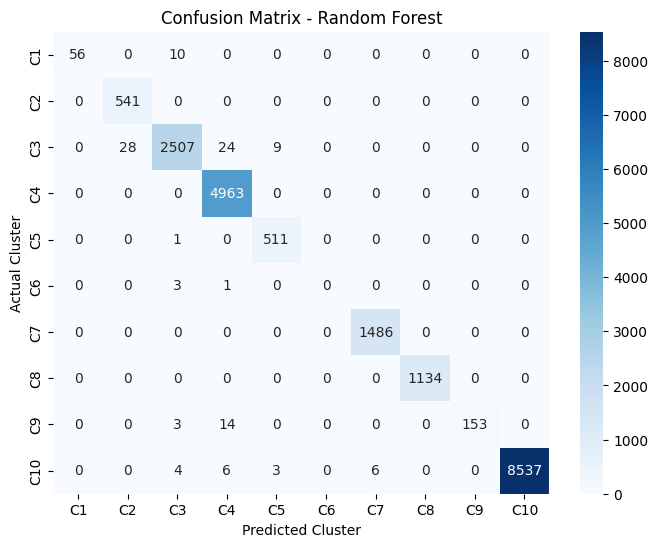

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Predict on validation set
rf_pred = rf_clf.predict(X_val)
lr_pred = lr_clf.predict(X_val)

# Calculate accuracy and F1-score
rf_accuracy = accuracy_score(y_val, rf_pred)
rf_f1_macro = f1_score(y_val, rf_pred, average='macro')
lr_accuracy = accuracy_score(y_val, lr_pred)
lr_f1_macro = f1_score(y_val, lr_pred, average='macro')

print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print(f"Random Forest Macro F1-score: {rf_f1_macro:.3f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.3f}")
print(f"Logistic Regression Macro F1-score: {lr_f1_macro:.3f}")

# Detailed classification report for Random Forest
print("\nClassification Report (Random Forest):")
print(classification_report(y_val, rf_pred))

# Confusion matrix for Random Forest
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, rf_pred, labels=sorted(y.unique(), key=lambda s: int(s[1:])))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=sorted(y.unique(), key=lambda s: int(s[1:])),
            yticklabels=sorted(y.unique(), key=lambda s: int(s[1:])), cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual Cluster")
plt.show()

The random forest’s performance is expected to be high. Each macro cluster (C1–C10) was defined by a combination of features (for example, C8 for low literacy patients if literacy_conf ≤ 3, C10 for high-risk patients if any of several risk factors like CKD, warfarin, or unstable INR apply, etc). The Random Forest should capture these decision rules. We print both accuracy and macro F1-score: high accuracy with a high macro-F1 indicates the model is performing well across all clusters, not just the most common ones. The confusion matrix gives insight into any systematic misclassifications (e.g., if the model confuses C3 vs C4, etc.).

We also compare to logistic regression: the logistic model will likely have lower accuracy, indicating that linear decision boundaries are not as effective for this problem. For instance, some clusters require AND conditions on features (which create non-linear boundaries). The Random Forest can naturally model those, whereas logistic regression might misclassify those cases. The classification report provides precision/recall/F1 per cluster to highlight which clusters are predicted well and which are more challenging.

# Feature Importance and Interpretation

In [ ]:
# Random Forest feature importance (top 10 features)
import numpy as np

importances = rf_clf.feature_importances_
feature_names = X_train.columns
# Get indices of top 10 important features
top_indices = np.argsort(importances)[-10:]
print("Top 10 Feature Importances (Random Forest):")
for idx in reversed(top_indices):
    print(f"  {feature_names[idx]}: {importances[idx]:.4f}")


Top 10 Feature Importances (Random Forest):
  oac_drug_Warfarin: 0.1932
  ckd: 0.1355
  portal_active: 0.1181
  autonomy: 0.0719
  has_bled: 0.0705
  literacy_conf: 0.0566
  low_literacy_proxy: 0.0523
  reply_rate2: 0.0397
  BRI: 0.0260
  open_rate2: 0.0245


This gives a quick overview of which features were most influential in the Random Forest splits. However, for a multi-class problem, simple importance scores might not tell the full story. We use SHAP values to understand how each feature influences the model's output for each class. SHAP values provide additive feature contributions for each prediction, which we can aggregate to see global patterns.

**(TTM Stage & Subcluster Classification)**
The current pipeline is modular and can be extended to predict other related targets. For example, we could build a similar classifier for a patient's Transtheoretical Model (TTM) stage (e.g., ttm_band like Precontemplation/Contemplation vs Action/Maintenance) or even the finer-grained subcluster_id. To do so, we would simply change the target variable (y) to the desired label and possibly adjust the feature set if needed (for instance, excluding BRI when predicting ttm_band if BRI was used to derive it). Then, the same preprocessing, model training, and evaluation steps would apply. We might also consider more advanced algorithms or hyperparameter tuning for these future models, but the overall approach would remain consistent.Sources